<a href="https://colab.research.google.com/github/thanh-huy/SIC_Excercies/blob/main/36_ex_0310.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Coding Exercise #0310

### 1. Classification with KNN:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics, preprocessing
warnings.filterwarnings(action='ignore')                  # Turn off the warnings.
%matplotlib inline

#### 1.1. Read in data:

The data and explanation can be found [here](https://www.kaggle.com/c/titanic/data) (requires sign in).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
df = pd.read_csv('/content/drive/MyDrive/mldata/data_titanic.csv', header='infer')

In [10]:
df.shape

(891, 12)

In [11]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


#### 1.2. Missing value processing:

In [12]:
# Check for the missing values.
df.isnull().sum(axis=0)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
# Fill the missing values in the Age variable.
n = df.shape[0]
Age = []                                                               # A temporary list.
for i in range(n):
    if np.isnan(df.Age[i]):
        if ('Mr' in df.Name[i]) or ('Mrs' in df.Name[i]) :
            Age.append(30)                        # If Mr. or Mrs. in the name, then fill with 30.
        else:
            Age.append(10)                        # Likely a child. So, fill with 10.
    else:
        Age.append(df.Age[i])
df.Age = pd.Series(Age)

In [15]:
# We will drop some columns.
df = df.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Fare', 'Cabin'])
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S


In [16]:
# Delete the rest of missing values.
df=df.dropna(axis=0)
df.shape

(889, 7)

In [17]:
df.shape

(889, 7)

#### 1.3. Exploratory data analysis:

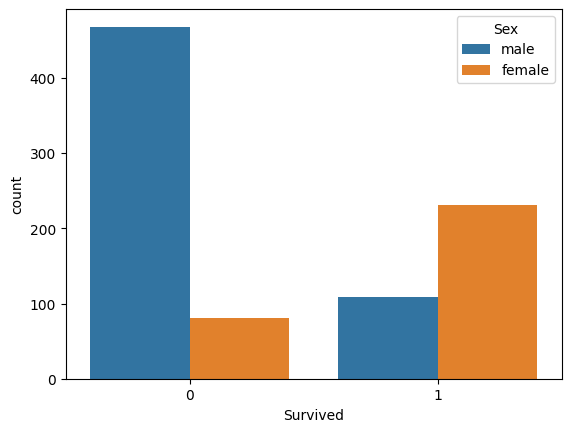

In [18]:
# The frequency table of Survived.
sns.countplot(x='Survived', hue="Sex", data=df)
plt.show()

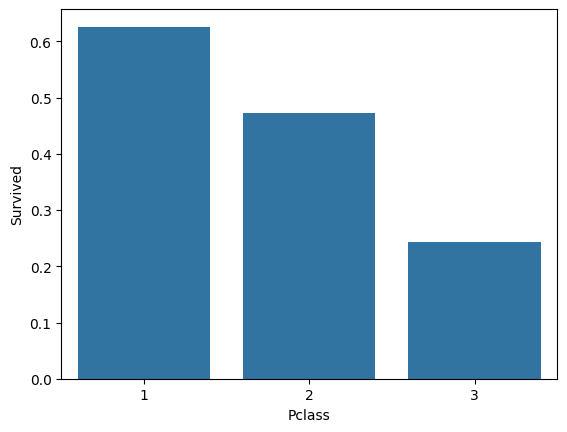

In [19]:
# Survival rate by Pclass.
sns.barplot(x='Pclass', y='Survived', ci=None, data=df)
plt.show()

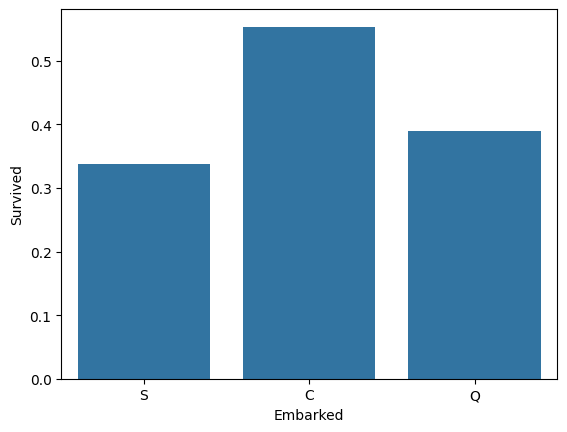

In [20]:
# Survival rate by Embarked.
sns.barplot(x='Embarked', y='Survived', ci=None, data=df)
plt.show()

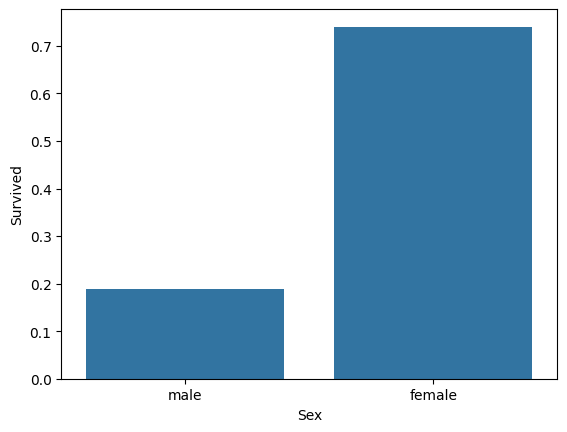

In [21]:
# Survival rate by Sex.
sns.barplot(x='Sex', y='Survived', ci=None,  data=df)
plt.show()

#### 1.4. Feature engineering:

In [22]:
# Convert into dummy variables and then remove the original variables.
df = pd.get_dummies(df, columns=['Pclass', 'Sex', 'Embarked'], drop_first=True)
df.head(5)

,Survived,Age,SibSp,Parch,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,22.0,1,0,False,True,True,False,True
1,1,38.0,1,0,False,False,False,False,False
2,1,26.0,0,0,False,True,False,False,True
3,1,35.0,1,0,False,False,False,False,True
4,0,35.0,0,0,False,True,True,False,True


In [23]:
# Save to an external file.
df.to_csv('data_titanic_2.csv', index=False)

#### 1.5. KNN train and test:

In [24]:
X = df.drop(columns=['Survived'])
Y = df['Survived']

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1234)

In [26]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(622, 8)
(267, 8)
(622,)
(267,)


In [27]:
# KNN with n_neighbours=5
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, Y_train);
Y_pred = knn5.predict(X_test)
print(metrics.confusion_matrix(Y_test, Y_pred))
print("------------------------")
print("Accuracy:", round(metrics.accuracy_score(Y_test, Y_pred), 3))

[[133  25]
 [ 46  63]]
------------------------
Accuracy: 0.734


In [28]:
# KNN with n_neighbours=100
knn100 = KNeighborsClassifier(n_neighbors=100)
knn100.fit(X_train, Y_train);
Y_pred = knn100.predict(X_test)
print(metrics.confusion_matrix(Y_test, Y_pred))
print("------------------------")
print("Accuracy:", round(metrics.accuracy_score(Y_test, Y_pred), 3))

[[145  13]
 [ 96  13]]
------------------------
Accuracy: 0.592


#### 1.6. KNN bias-Variance tradeoff as function of *k*:

In [29]:
accs = []
k_grid = range(1, 100, 1)
for k in k_grid:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    Y_pred = knn.predict(X_test)
    accs.append(metrics.accuracy_score(Y_test, Y_pred))

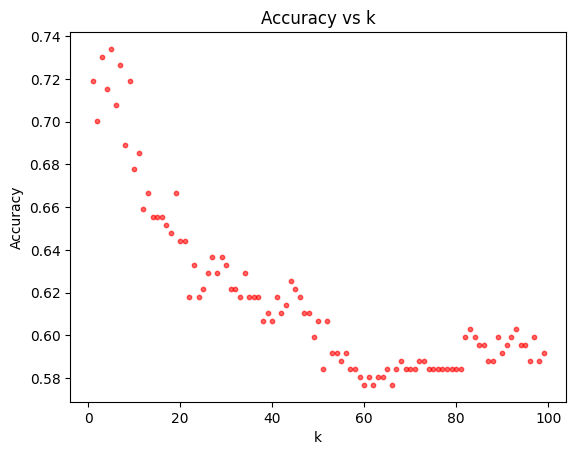

In [30]:
# Visualize.
plt.scatter(k_grid, accs, c='red', marker='o', s=10, alpha=0.6)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy vs k')
plt.show()

#### 1.7. KNN hyperparameter optimization:

In [31]:
# Parameter grid.
k_grid = range(1, 51, 1)
parameters = {'n_neighbors': k_grid}

In [32]:
# Optimize the k.
gridCV = GridSearchCV(KNeighborsClassifier(),
                      parameters,
                      cv=10,
                      n_jobs=-1)       # "n_jobs = -1" means "use all the CPU cores".
gridCV.fit(X_train, Y_train)
best_k = gridCV.best_params_['n_neighbors']
print("Best k:", best_k)

Best k: 3


In [33]:
# Test with the best k.
KNN_best = KNeighborsClassifier(n_neighbors=best_k)
KNN_best.fit(X_train, Y_train)
Y_pred = KNN_best.predict(X_test)
print( "Best Accuracy:", round(metrics.accuracy_score(Y_test,Y_pred), 3))

Best Accuracy: 0.73
